# Behavioural Risk Modeling + PHQ-9 Validation

## Notebook Sections

1. **Pre-process**
2. **Model 1 steps** (Primary behavioural model)
3. **Model 2 steps** (Secondary PHQ-9 validation model)

## Step 0 — Original objective (from Agents.md)

### Main objective: behavioural intervention model (primary trigger)
- Use only phone-use behavioural features.
- Produce actionable outputs: domain scores, behavioural risk tier, top drivers.
- Support intervention planning (not diagnosis).

### Secondary objective: PHQ-9 validation model (supporting evidence)
- Predict `PHQ9_10plus` from behavioural signals to test association strength.
- Keep this as validation/supporting evidence, not the trigger.

### How this notebook is organized
- **Pre-process:** Steps 0 to 4B
- **Model 1 steps:** Step 5 (primary behavioural tier + drivers)
- **Model 2 steps:** Steps 6 to 10 (secondary validation, threshold/error analysis, and final integration)

In [18]:
# Setup for reproducible analysis and modeling
import warnings
warnings.filterwarnings('ignore')

# Core data and visualization libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Modeling utilities for both main (behavioural) and secondary (PHQ validation) tasks
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, balanced_accuracy_score,
    precision_score, confusion_matrix
)

# Fixed seed for reproducibility across runs
SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

**Result interpretation (Step 0 setup)**
- No visible output is expected here; this is a configuration cell.
- Successful execution means imports and reproducibility settings loaded correctly.
- This enables all later cells for both the main behavioural model and secondary PHQ-9 validation model.

## Section 1 — Pre-process

## Step 1 — Load canonical data and check target quality
- **Goal linked to objective:** confirm the primary dataset is usable before building behavioural and validation models.
- We load `data/DSA4262_Survey_Cleaned.csv` and inspect shape, class balance, and missing target values.
- **How to interpret output:** class imbalance (`38` vs `12`) is expected and informs model-evaluation strategy in later steps.

In [19]:
# Load canonical cleaned dataset used throughout this notebook
df = pd.read_csv('../data/DSA4262_Survey_Cleaned.csv')

# Quick diagnostics: size, target class balance, and missingness
print('Shape:', df.shape)
print('PHQ9_10plus distribution:')
print(df['PHQ9_10plus'].value_counts(dropna=False))
print('Missing PHQ9_10plus:', df['PHQ9_10plus'].isna().sum())

Shape: (50, 97)
PHQ9_10plus distribution:
PHQ9_10plus
0    38
1    12
Name: count, dtype: int64
Missing PHQ9_10plus: 0


**Result interpretation (Step 1 data checks)**
- Data shape is `50 x 97`, so the notebook has the expected compact sample with broad feature coverage.
- `PHQ9_10plus` distribution is `38` negatives vs `12` positives, indicating class imbalance.
- Missing target count is `0`, so secondary-model training/evaluation can proceed without dropping target-null rows.

## Step 2 — Enforce schema and value integrity (fail-fast)
- **Goal linked to objective:** ensure all downstream decisions are based on valid, expected survey fields and scales.
- This checks required columns, numeric ranges, and binary encoding for `PHQ9_10plus`.
- **How to interpret output:** pass message means the data can safely enter feature engineering and modeling.

In [20]:
# Define required columns from schema so failures are caught early
required_cols = ['PHQ9_Total', 'PHQ9_10plus'] + [
    'Q4_DailyPhoneTime_num', 'Q5_CheckFrequency_num', 'Q6_AfterWakeCheck_num',
    'Q7_After11PMUse_num', 'Q8_StopUseAtNight_num', 'Q10_SocialMediaTime_num',
    'Q11_PhoneDuringMeals_num', 'Q12_PhoneDuringWorkClass_num', 'Q13_CheckDuringTasks_num',
    'Q14_NotificationsInterrupt_num', 'Q15_UseWhenBored_num', 'Q16_UseWhenStressed_num',
    'Q17_DistractNegativeEmotions_num', 'Q18_PhoneInBed_num', 'Q19_PhoneDelaysSleep_num',
    'Q20_NotificationsWakeNight_num', 'Q21_WakeToCheckPhone_num', 'Q22_UnlockWithoutReason_num',
    'Q23_UseLongerThanIntended_A_num', 'Q24_FailToReduceUse_num',
    'Q25_MissPlannedWork_num', 'Q26_ConcentrationProblems_num', 'Q27_PhysicalPain_num',
    'Q28_CannotStandWithoutPhone_num', 'Q29_ImpatientWithoutPhone_num', 'Q30_PhoneOnMyMind_num',
    'Q31_WontGiveUpPhone_num', 'Q32_ConstantChecking_num', 'Q33_UseLongerThanIntended_B_num',
    'Q34_OthersSayTooMuchUse_num',
    'Q35_PHQ1_Interest_num', 'Q36_PHQ2_Down_num', 'Q37_PHQ3_Sleep_num', 'Q38_PHQ4_Tired_num',
    'Q39_PHQ5_Appetite_num', 'Q40_PHQ6_SelfWorth_num', 'Q41_PHQ7_Concentration_num',
    'Q42_PHQ8_RestlessSlow_num', 'Q43_PHQ9_SelfHarm_num'
]
missing_cols = [c for c in required_cols if c not in df.columns]
assert len(missing_cols) == 0, f'Missing required columns: {missing_cols}'

# Expected value ranges by item block
range_rules = {
    'Q4_DailyPhoneTime_num': (1, 5),
    'Q5_CheckFrequency_num': (1, 4),
    'Q6_AfterWakeCheck_num': (1, 4),
    'Q7_After11PMUse_num': (1, 5),
    'Q8_StopUseAtNight_num': (1, 5),
    'Q10_SocialMediaTime_num': (1, 5),
    'PHQ9_Total': (0, 27),
}

for c in [
    'Q11_PhoneDuringMeals_num','Q12_PhoneDuringWorkClass_num','Q13_CheckDuringTasks_num','Q14_NotificationsInterrupt_num',
    'Q15_UseWhenBored_num','Q16_UseWhenStressed_num','Q17_DistractNegativeEmotions_num','Q18_PhoneInBed_num',
    'Q19_PhoneDelaysSleep_num','Q20_NotificationsWakeNight_num','Q21_WakeToCheckPhone_num','Q22_UnlockWithoutReason_num',
    'Q23_UseLongerThanIntended_A_num','Q24_FailToReduceUse_num',
]:
    range_rules[c] = (1, 5)

for c in [
    'Q25_MissPlannedWork_num','Q26_ConcentrationProblems_num','Q27_PhysicalPain_num','Q28_CannotStandWithoutPhone_num',
    'Q29_ImpatientWithoutPhone_num','Q30_PhoneOnMyMind_num','Q31_WontGiveUpPhone_num','Q32_ConstantChecking_num',
    'Q33_UseLongerThanIntended_B_num','Q34_OthersSayTooMuchUse_num'
]:
    range_rules[c] = (1, 6)

for c in [
    'Q35_PHQ1_Interest_num','Q36_PHQ2_Down_num','Q37_PHQ3_Sleep_num','Q38_PHQ4_Tired_num',
    'Q39_PHQ5_Appetite_num','Q40_PHQ6_SelfWorth_num','Q41_PHQ7_Concentration_num',
    'Q42_PHQ8_RestlessSlow_num','Q43_PHQ9_SelfHarm_num'
]:
    range_rules[c] = (0, 3)

# Fail if any values are outside the expected scale
for col, (lo, hi) in range_rules.items():
    series = pd.to_numeric(df[col], errors='coerce')
    out = series.dropna().loc[(series.dropna() < lo) | (series.dropna() > hi)]
    assert out.empty, f'{col} out of range [{lo}, {hi}] count={len(out)}'

# Normalize target to integer 0/1 where needed
if df['PHQ9_10plus'].dtype == bool:
    df['PHQ9_10plus'] = df['PHQ9_10plus'].astype(int)
elif str(df['PHQ9_10plus'].dtype) == 'object':
    df['PHQ9_10plus'] = df['PHQ9_10plus'].map({True: 1, False: 0, 'True': 1, 'False': 0, '1': 1, '0': 0})

valid_target_vals = set(df['PHQ9_10plus'].dropna().astype(int).unique().tolist())
assert valid_target_vals.issubset({0, 1}), f'Invalid PHQ9_10plus values: {valid_target_vals}'

print('Schema checks passed: columns/ranges/target type are valid.')

Schema checks passed: columns/ranges/target type are valid.


**Result interpretation (Step 2 schema validation)**
- `Schema checks passed` confirms required columns, value ranges, and target encoding are valid.
- This reduces risk of silent preprocessing errors that could distort risk tiers or model metrics.
- Because validation passes, downstream interpretations can be treated as methodologically grounded.

## Step 3 — Build interpretable behavioural domain scores
- **Goal linked to objective:** create transparent behavioural dimensions that directly support intervention messaging.
- Map items into exposure, context, emotional, sleep, and self-regulation domains.
- **How to interpret output:** higher means indicate stronger behavioural risk signals in that domain.

In [21]:
# Domain definitions from Agents.md mapping template
domain_map = {
    'exposure_intensity': [
        'Q4_DailyPhoneTime_num','Q5_CheckFrequency_num','Q6_AfterWakeCheck_num',
        'Q7_After11PMUse_num','Q8_StopUseAtNight_num','Q10_SocialMediaTime_num'
    ],
    'context_disruption': [
        'Q11_PhoneDuringMeals_num','Q12_PhoneDuringWorkClass_num','Q13_CheckDuringTasks_num','Q14_NotificationsInterrupt_num'
    ],
    'emotional_coping': [
        'Q15_UseWhenBored_num','Q16_UseWhenStressed_num','Q17_DistractNegativeEmotions_num'
    ],
    'sleep_disruption': [
        'Q18_PhoneInBed_num','Q19_PhoneDelaysSleep_num','Q20_NotificationsWakeNight_num','Q21_WakeToCheckPhone_num'
    ],
    'self_regulation': [
        'Q22_UnlockWithoutReason_num','Q23_UseLongerThanIntended_A_num','Q24_FailToReduceUse_num'
    ],
}

# Optional PSU-style severity items
psu_cols = [
    'Q25_MissPlannedWork_num','Q26_ConcentrationProblems_num','Q27_PhysicalPain_num','Q28_CannotStandWithoutPhone_num',
    'Q29_ImpatientWithoutPhone_num','Q30_PhoneOnMyMind_num','Q31_WontGiveUpPhone_num','Q32_ConstantChecking_num',
    'Q33_UseLongerThanIntended_B_num','Q34_OthersSayTooMuchUse_num'
]

# Common helper to scale different Likert ranges into a shared 0-100 score
def norm_0_100(series, lo, hi):
    return (series - lo) / (hi - lo) * 100

# Set per-item source scale for correct normalization
item_range = {}
for c in domain_map['exposure_intensity']:
    item_range[c] = (1, 4) if c in {'Q5_CheckFrequency_num','Q6_AfterWakeCheck_num'} else (1, 5)
for k in ['context_disruption','emotional_coping','sleep_disruption','self_regulation']:
    for c in domain_map[k]:
        item_range[c] = (1, 5)
for c in psu_cols:
    item_range[c] = (1, 6)

# Compute domain means (interpretable behavioural dimensions)
for dname, cols in domain_map.items():
    scaled_items = []
    for c in cols:
        lo, hi = item_range[c]
        scaled_items.append(norm_0_100(df[c].astype(float), lo, hi))
    df[f'domain_{dname}'] = pd.concat(scaled_items, axis=1).mean(axis=1)

# Optional overall severity signal based on Q25-Q34
scaled_psu = [norm_0_100(df[c].astype(float), 1, 6) for c in psu_cols]
df['psu_style_score'] = pd.concat(scaled_psu, axis=1).mean(axis=1)

domain_cols = [c for c in df.columns if c.startswith('domain_')]
df[domain_cols + ['psu_style_score']].describe().T[['mean','std','min','max']]

,mean,std,min,max
domain_exposure_intensity,69.527778,15.246593,37.50,94.444444
domain_context_disruption,60.750000,14.673313,37.50,87.500000
domain_emotional_coping,71.833333,20.612091,0.00,100.000000
domain_sleep_disruption,44.500000,11.268409,6.25,62.500000
domain_self_regulation,56.000000,20.135595,0.00,100.000000
psu_style_score,43.480000,17.837406,14.00,90.000000


**Result interpretation (Step 3 domain scores)**
- Average scores are highest for `domain_emotional_coping` (~71.8) and `domain_exposure_intensity` (~69.5).
- `domain_sleep_disruption` is lower on average (~44.5), suggesting this cohort’s strongest signals are not primarily sleep-driven.
- These domain values are the main ingredients for the primary behavioural risk tier and top-driver explanations.

## Step 4A — PCA for latent behavioural dimensions
- **Goal linked to objective:** summarize many behavioural variables into a few interpretable latent components.
- PCA captures dominant variance structure across phone-use behaviours.
- **How to interpret output:** explained variance ratios show how much behaviour variability each component captures; top loadings show which variables drive each component.

In [22]:
# Theory-driven features to represent hypothesized behavioural interactions
theory_features = domain_cols + [
    'domain_exposure_sleep_interaction',
    'domain_emotion_selfreg_interaction'
]

df['domain_exposure_sleep_interaction'] = (df['domain_exposure_intensity'] * df['domain_sleep_disruption']) / 100
df['domain_emotion_selfreg_interaction'] = (df['domain_emotional_coping'] * df['domain_self_regulation']) / 100

# Data-driven matrix: item-level behavioural features
behaviour_item_cols = sorted({c for cols in domain_map.values() for c in cols}.union(set(psu_cols)))
X_items = df[behaviour_item_cols].astype(float).fillna(df[behaviour_item_cols].median())

# Standardize and run PCA
scaler = StandardScaler()
X_std = scaler.fit_transform(X_items)
pca = PCA(n_components=5, random_state=SEED)
X_pca = pca.fit_transform(X_std)

# PCA variance belongs to components (PC1..PC5), each driven by multiple variables via loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=behaviour_item_cols,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

# Show top absolute-loading variables for each component
pc_top_features = {}
for pc in loadings.columns:
    top = loadings[pc].abs().sort_values(ascending=False).head(5).index.tolist()
    pc_top_features[pc] = top

print('PCA explained variance ratio:', np.round(pca.explained_variance_ratio_, 3))
print('Top variables by absolute loading per component:')
for pc, vars_ in pc_top_features.items():
    print(f'{pc}: {vars_}')

PCA explained variance ratio: [0.29  0.086 0.074 0.063 0.058]
Top variables by absolute loading per component:
PC1: ['Q26_ConcentrationProblems_num', 'Q33_UseLongerThanIntended_B_num', 'Q30_PhoneOnMyMind_num', 'Q16_UseWhenStressed_num', 'Q22_UnlockWithoutReason_num']
PC2: ['Q20_NotificationsWakeNight_num', 'Q8_StopUseAtNight_num', 'Q21_WakeToCheckPhone_num', 'Q7_After11PMUse_num', 'Q19_PhoneDelaysSleep_num']
PC3: ['Q10_SocialMediaTime_num', 'Q12_PhoneDuringWorkClass_num', 'Q4_DailyPhoneTime_num', 'Q25_MissPlannedWork_num', 'Q21_WakeToCheckPhone_num']
PC4: ['Q29_ImpatientWithoutPhone_num', 'Q6_AfterWakeCheck_num', 'Q28_CannotStandWithoutPhone_num', 'Q5_CheckFrequency_num', 'Q31_WontGiveUpPhone_num']
PC5: ['Q27_PhysicalPain_num', 'Q28_CannotStandWithoutPhone_num', 'Q5_CheckFrequency_num', 'Q32_ConstantChecking_num', 'Q11_PhoneDuringMeals_num']


**Result interpretation (Step 4A PCA)**
- PCA variance ratios `[0.29, 0.086, 0.074, 0.063, 0.058]` mean `PC1` explains `29%` of standardized behavioural variance, followed by smaller components.
- Variance is associated with **components**, and each component is associated with variables via loadings.
- Current strongest contributors by component are:
  - `PC1` (29%): concentration/compulsion-stress items (`Q26`, `Q33`, `Q30`, `Q16`, `Q22`).
  - `PC2` (8.6%): night/sleep disruption items (`Q20`, `Q8`, `Q21`, `Q7`, `Q19`).
  - `PC3` (7.4%): social-media/time + work-class use mix (`Q10`, `Q12`, `Q4`, `Q25`, `Q21`).
  - `PC4` (6.3%): impatience/checking/compulsion mix (`Q29`, `Q6`, `Q28`, `Q5`, `Q31`).
  - `PC5` (5.8%): physical pain + checking/context mix (`Q27`, `Q28`, `Q5`, `Q32`, `Q11`).

## Step 4B — KMeans clustering and visualization
- **Goal linked to objective:** identify distinct behavioural profiles for segmentation support.
- KMeans groups users with similar behavioural patterns.
- **How to interpret output:** cluster counts show profile sizes; the scatter plot (PC1 vs PC2) visualizes separation and overlap between profiles.

Cluster counts: {0: 8, 1: 16, 2: 26}


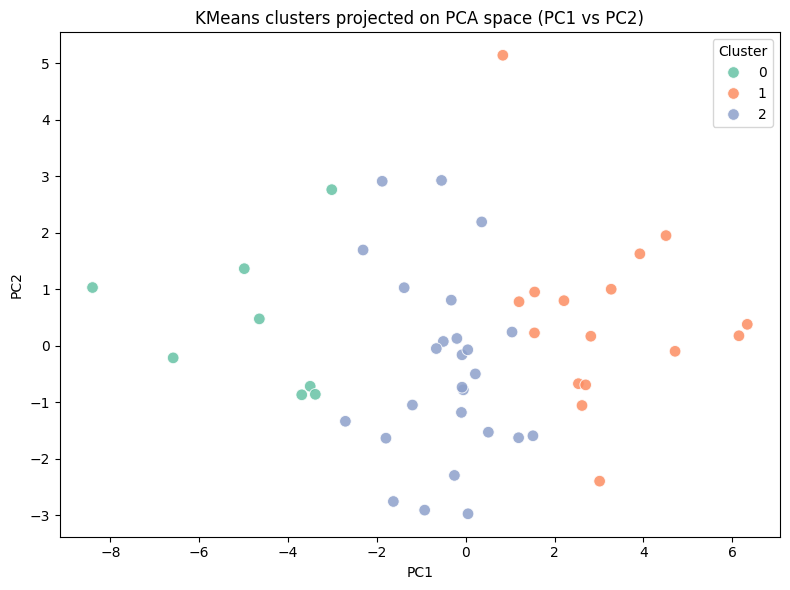

In [23]:
# Fit KMeans on standardized behavioural matrix
kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=20)
cluster_labels = kmeans.fit_predict(X_std)

# Attach cluster labels for downstream analysis
df['kmeans_cluster'] = cluster_labels
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print('Cluster counts:', cluster_counts.to_dict())

# Visualize clusters in the first two PCA dimensions
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'cluster': cluster_labels.astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='cluster', palette='Set2', s=70, alpha=0.85)
plt.title('KMeans clusters projected on PCA space (PC1 vs PC2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

**Result interpretation (Step 4B KMeans)**
- Cluster counts summarize profile sizes (currently expected around `{0: 8, 1: 16, 2: 26}` unless data/cells are rerun with changes).
- The PC1–PC2 scatter shows how distinctly the profiles separate in reduced feature space.
- More overlap means softer boundaries between behaviour profiles; clearer separation means stronger profile structure.
    - strong left-vs-right split (cluster 0 vs 1),
    - softer boundary for the middle profile (cluster 2), which looks like an intermediate/mixed behaviour group rather than a sharply distinct type.

## Section 2 — Model 1 steps

## Step 5 — Construct main behavioural risk tier and drivers
- **Goal linked to objective:** produce the primary intervention trigger and explain *why* each user is flagged.
- Uses phone-use-only features with explicit guards against PHQ and demographic leakage into the trigger.
- Domain weights can be set as theory-driven defaults or estimated from a behavioural-only model (PCA on domain scores).
- **How to interpret output:** `behavioural_risk_tier` drives intervention priority; `top_driver_1..3` guides personalized nudges.

### How Model 1 derives PCA-based weights (one-to-one)
1. Build `domain_matrix` from the 5 domain scores.
2. Standardize it into `domain_std` so domains are on comparable scale.
3. Fit PCA with `n_components=1` to capture the strongest shared pattern.
4. Read PC1 loadings from `domain_pca.components_[0]`.
5. Take absolute values (`loading_abs`) to keep contribution magnitudes positive.
6. Normalize by sum (`loading_norm`) so values add up to `1.0`.
7. Map normalized values to domain names as `weights`.
8. Compute `behavioural_risk_index` as weighted sum of domain scores.
9. Convert index to `low/moderate/high` via quantile cutoffs.

In [ ]:
# Main-model features start from behavioural items only
main_behavioural_features = behaviour_item_cols.copy()

# Guardrails from Agents.md: no PHQ items and no demographics in primary trigger
for forbidden in [f'Q{i}_PHQ' for i in range(35, 44)]:
    assert all(forbidden not in c for c in main_behavioural_features), 'PHQ predictors leaked into main model features'
assert not any(c.startswith('Q2_Gender_') or c.startswith('Q3_Status_') or c == 'Q1_Age' for c in main_behavioural_features), 'Demographics leaked into main model features'

# Define the domain columns used to build the behavioural risk index
domain_feature_cols = [
    'domain_exposure_intensity',
    'domain_context_disruption',
    'domain_emotional_coping',
    'domain_sleep_disruption',
    'domain_self_regulation',
]

# Choose how to obtain weights: 'theory' (manual) or 'pca_data_driven' (learned from behavioural domains)
WEIGHT_MODE = 'pca_data_driven'

if WEIGHT_MODE == 'theory':
    # Manual baseline weights (sum to 1.0)
    weights = {
        'domain_exposure_intensity': 0.22,
        'domain_context_disruption': 0.18,
        'domain_emotional_coping': 0.20,
        'domain_sleep_disruption': 0.20,
        'domain_self_regulation': 0.20,
    }
elif WEIGHT_MODE == 'pca_data_driven':
    # 1) Build matrix of the 5 domain scores
    domain_matrix = df[domain_feature_cols].astype(float)

    # 2) Standardize so all domains are comparable before PCA
    domain_scaler = StandardScaler()
    domain_std = domain_scaler.fit_transform(domain_matrix)

    # 3) Fit PCA with one component = strongest shared behavioural pattern
    domain_pca = PCA(n_components=1, random_state=SEED)
    domain_pca.fit(domain_std)

    # 4) Take absolute PC1 loadings as contribution strengths
    loading_abs = np.abs(domain_pca.components_[0])

    # 5) Normalize strengths so weights add up to 1.0
    loading_norm = loading_abs / loading_abs.sum()

    # 6) Assign normalized contributions back to domain names
    weights = dict(zip(domain_feature_cols, loading_norm))
else:
    raise ValueError("WEIGHT_MODE must be either 'theory' or 'pca_data_driven'")

print('Weight mode:', WEIGHT_MODE)
print('Domain weights:', {k: round(float(v), 4) for k, v in weights.items()})

# 7) Build weighted behavioural risk index from domain scores
df['behavioural_risk_index'] = sum(df[k] * v for k, v in weights.items())
q1, q2 = df['behavioural_risk_index'].quantile([0.33, 0.66])

# 8) Convert index into intervention tiers using quantile cutoffs
df['behavioural_risk_tier'] = pd.cut(
    df['behavioural_risk_index'],
    bins=[-np.inf, q1, q2, np.inf],
    labels=['low', 'moderate', 'high']
)

# Driver attribution: rank highest scoring domains per user
driver_domains = list(weights.keys())
driver_labels = {
    'domain_exposure_intensity': 'exposure_intensity',
    'domain_context_disruption': 'context_disruption',
    'domain_emotional_coping': 'emotional_coping',
    'domain_sleep_disruption': 'sleep_disruption',
    'domain_self_regulation': 'self_regulation',
}

def top_drivers(row, n=3):
    ranked = sorted(driver_domains, key=lambda c: row[c], reverse=True)[:n]
    return [driver_labels[c] for c in ranked]

# Make reruns safe by removing prior driver columns before recomputing
existing_driver_cols = [c for c in ['top_driver_1', 'top_driver_2', 'top_driver_3'] if c in df.columns]
if existing_driver_cols:
    df = df.drop(columns=existing_driver_cols)

drivers = df.apply(top_drivers, axis=1, result_type='expand')
drivers.columns = ['top_driver_1', 'top_driver_2', 'top_driver_3']
df = pd.concat([df, drivers], axis=1)

# Primary signal-to-decision output table (main intervention artifact)
signal_to_decision_df = pd.DataFrame({
    'row_id': np.arange(len(df)),
    'behavioural_risk_tier': df['behavioural_risk_tier'].astype(str),
    'domain_exposure_intensity': df['domain_exposure_intensity'],
    'domain_context_disruption': df['domain_context_disruption'],
    'domain_emotional_coping': df['domain_emotional_coping'],
    'domain_sleep_disruption': df['domain_sleep_disruption'],
    'domain_self_regulation': df['domain_self_regulation'],
    'top_driver_1': df['top_driver_1'],
    'top_driver_2': df['top_driver_2'],
    'top_driver_3': df['top_driver_3'],
    'psu_style_score': df['psu_style_score'],
})

signal_to_decision_df.head()

Weight mode: pca_data_driven
Domain weights: {'domain_exposure_intensity': 0.2039, 'domain_context_disruption': 0.1914, 'domain_emotional_coping': 0.2116, 'domain_sleep_disruption': 0.2032, 'domain_self_regulation': 0.1899}


,row_id,behavioural_risk_tier,domain_exposure_intensity,domain_context_disruption,domain_emotional_coping,domain_sleep_disruption,domain_self_regulation,top_driver_1,top_driver_2,top_driver_3,psu_style_score
0,0,low,37.500000,37.5,58.333333,25.0,41.666667,emotional_coping,self_regulation,exposure_intensity,18.0
1,1,high,91.666667,87.5,100.000000,62.5,100.000000,emotional_coping,self_regulation,exposure_intensity,76.0
2,2,low,45.833333,37.5,58.333333,37.5,58.333333,emotional_coping,self_regulation,exposure_intensity,28.0
3,3,moderate,76.388889,62.5,75.000000,62.5,25.000000,exposure_intensity,emotional_coping,context_disruption,20.0
4,4,high,90.277778,87.5,100.000000,50.0,100.000000,emotional_coping,self_regulation,exposure_intensity,34.0


**Result interpretation (Step 5 primary behavioural output)**
- The preview confirms required primary-output fields are generated: risk tier, domain scores, top drivers, and PSU-style score.
- Rows show meaningful differentiation across users (e.g., `low`, `moderate`, `high` tiers), which supports intervention prioritization.
- This table is the main decision signal and remains independent of PHQ-item predictors.

## Section 3 — Model 2 steps

## Step 6 — Train secondary PHQ-9 association models (non-primary)
- **Goal linked to objective:** test whether behavioural features carry signal for elevated PHQ burden.
- Compare interpretable and nonlinear models using stratified CV and required metrics.
- **How to interpret output:** selected model quality indicates validation strength, not intervention authority.

In [25]:
# Secondary task features: behavioural items (+ optional app usage indicators)
app_cols = [
    c for c in [
        'Q9_App_SocialMedia','Q9_App_Messaging','Q9_App_ProductivityStudy','Q9_App_WebBrowsing',
        'Q9_App_VideoStreaming','Q9_App_Gaming','Q9_App_Shopping'
    ] if c in df.columns
]

secondary_features = behaviour_item_cols + app_cols
X_sec = df[secondary_features].copy()

# Convert booleans and ensure numeric matrix for sklearn
for c in X_sec.columns:
    if X_sec[c].dtype == bool:
        X_sec[c] = X_sec[c].astype(int)
X_sec = X_sec.apply(pd.to_numeric, errors='coerce').fillna(X_sec.median(numeric_only=True))
y = df['PHQ9_10plus'].astype(int)

# Candidate models required by project brief
models = {
    'logistic_regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED))
    ]),
    'random_forest': RandomForestClassifier(
        n_estimators=400, class_weight='balanced', random_state=SEED
    ),
    'hist_gradient_boosting': HistGradientBoostingClassifier(random_state=SEED)
}

# Stratified CV and required evaluation metrics
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'recall': 'recall',
    'balanced_accuracy': 'balanced_accuracy'
}

rows = []
for name, model in models.items():
    cv_res = cross_validate(model, X_sec, y, cv=cv, scoring=scoring, n_jobs=None)
    rows.append({
        'model': name,
        'roc_auc_mean': np.mean(cv_res['test_roc_auc']),
        'f1_mean': np.mean(cv_res['test_f1']),
        'recall_mean': np.mean(cv_res['test_recall']),
        'balanced_accuracy_mean': np.mean(cv_res['test_balanced_accuracy'])
    })

comparison_df = pd.DataFrame(rows)

# Rank by threshold-sensitive utility first (F1, Recall), then discrimination (ROC-AUC)
comparison_df = comparison_df.sort_values(
    ['f1_mean', 'recall_mean', 'roc_auc_mean'], ascending=False
).reset_index(drop=True)

selected_model_name = comparison_df.iloc[0]['model']
print('Selected validation model (ranked by F1, Recall, ROC-AUC):', selected_model_name)

comparison_df

Selected validation model (ranked by F1, Recall, ROC-AUC): logistic_regression


,model,roc_auc_mean,f1_mean,recall_mean,balanced_accuracy_mean
0,logistic_regression,0.525595,0.214286,0.366667,0.51369
1,hist_gradient_boosting,0.626190,0.000000,0.000000,0.50000
2,random_forest,0.550595,0.000000,0.000000,0.46250


**Result interpretation (Step 6 secondary model comparison)**
- Selected model is `logistic_regression` when ranking by `F1`, `Recall`, then `ROC-AUC`.
- Although boosting has higher ROC-AUC, its `F1=0` and `Recall=0`, so it is not useful for identifying positives at the tested operating behavior.
- Interpretation: secondary PHQ association signal exists but predictive utility is modest on this small, imbalanced sample.

## Step 7 — Threshold behavior on holdout data
- **Goal linked to objective:** understand practical decision behavior for the secondary model.
- Evaluate precision/recall/F1 trade-offs across candidate thresholds.
- **How to interpret output:** weak threshold performance means secondary probabilities should remain supporting evidence only.

In [26]:
# Use selected secondary model for holdout threshold diagnostics
best_model_name = selected_model_name
best_model = models[best_model_name]

# Holdout split for threshold behavior checks
X_train, X_test, y_train, y_test = train_test_split(
    X_sec, y, test_size=0.25, stratify=y, random_state=SEED
)

best_model.fit(X_train, y_train)
test_proba = best_model.predict_proba(X_test)[:, 1]

# Evaluate fixed thresholds required by project framing
thresholds = [0.30, 0.40, 0.50]
thr_rows = []
for thr in thresholds:
    pred = (test_proba >= thr).astype(int)
    thr_rows.append({
        'threshold': thr,
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_test, pred)
    })
thr_df = pd.DataFrame(thr_rows)
thr_df

,threshold,precision,recall,f1,balanced_accuracy
0,0.3,0.0,0.0,0.0,0.25
1,0.4,0.0,0.0,0.0,0.30
2,0.5,0.0,0.0,0.0,0.30


**Result interpretation (Step 7 threshold table)**
- At thresholds `0.30`, `0.40`, and `0.50`, precision/recall/F1 are all `0` on this holdout split.
- Balanced accuracy remains low (`0.25–0.30`), indicating weak threshold-level discrimination in this run.
- Operationally, this reinforces that secondary outputs should remain supporting evidence rather than trigger logic.

## Step 8 — Confusion-matrix trade-off analysis
- **Goal linked to objective:** quantify intervention-relevant errors for the secondary model at a chosen threshold.
- **How to interpret output:** `FN` means missed potentially at-risk users; `FP` means extra low-intensity interventions.
- This section supports threshold governance but does not change the primary trigger (main behavioural tier).

In [27]:
# Choose an operating threshold for confusion-matrix interpretation
chosen_threshold = 0.40
test_pred = (test_proba >= chosen_threshold).astype(int)
cm = confusion_matrix(y_test, test_pred)
tn, fp, fn, tp = cm.ravel()

# Print error profile for intervention trade-offs
print(f'Selected model: {best_model_name}')
print(f'Chosen threshold: {chosen_threshold}')
print('Confusion matrix [[TN, FP],[FN, TP]]:')
print(cm)
print(f'False positives: {fp}')
print(f'False negatives: {fn}')
print('Interpretation: FN implies missed at-risk users; FP implies extra low-intensity nudges.')

Selected model: logistic_regression
Chosen threshold: 0.4
Confusion matrix [[TN, FP],[FN, TP]]:
[[6 4]
 [3 0]]
False positives: 4
False negatives: 3
Interpretation: FN implies missed at-risk users; FP implies extra low-intensity nudges.


**Result interpretation (Step 8 confusion matrix)**
- Confusion matrix `[[6, 4], [3, 0]]` at threshold `0.40` gives `4` false positives and `3` false negatives with `0` true positives.
- This means the secondary model currently misses all positives in this specific split while still generating unnecessary alerts.
- Decision implication: keep emphasis on main behavioural tier and treat secondary probability as contextual metadata only.

## Step 9 — Final signal-to-decision table
- **Goal linked to objective:** combine primary behavioural outputs with secondary association estimate into one user-level table.
- Main behavioural columns remain the intervention driver; secondary probability is context/support.
- This is the final handoff artifact for downstream decision support.

In [28]:
# Refit selected secondary model on full data for final probability estimates
best_model.fit(X_sec, y)
signal_to_decision_df['phq9_association_risk_estimate'] = best_model.predict_proba(X_sec)[:, 1]

# Keep final schema aligned with project brief
final_cols = [
    'row_id', 'behavioural_risk_tier',
    'domain_exposure_intensity', 'domain_context_disruption', 'domain_emotional_coping',
    'domain_sleep_disruption', 'domain_self_regulation',
    'top_driver_1', 'top_driver_2', 'top_driver_3',
    'psu_style_score', 'phq9_association_risk_estimate'
]

signal_to_decision_df = signal_to_decision_df[final_cols]
signal_to_decision_df.head(10)

,row_id,behavioural_risk_tier,domain_exposure_intensity,domain_context_disruption,domain_emotional_coping,domain_sleep_disruption,domain_self_regulation,top_driver_1,top_driver_2,top_driver_3,psu_style_score,phq9_association_risk_estimate
0,0,low,37.500000,37.50,58.333333,25.00,41.666667,emotional_coping,self_regulation,exposure_intensity,18.0,0.000248
1,1,high,91.666667,87.50,100.000000,62.50,100.000000,emotional_coping,self_regulation,exposure_intensity,76.0,0.952366
2,2,low,45.833333,37.50,58.333333,37.50,58.333333,emotional_coping,self_regulation,exposure_intensity,28.0,0.000077
3,3,moderate,76.388889,62.50,75.000000,62.50,25.000000,exposure_intensity,emotional_coping,context_disruption,20.0,0.607871
4,4,high,90.277778,87.50,100.000000,50.00,100.000000,emotional_coping,self_regulation,exposure_intensity,34.0,0.053918
5,5,low,75.000000,62.50,33.333333,50.00,50.000000,exposure_intensity,context_disruption,sleep_disruption,44.0,0.035805
6,6,low,54.166667,43.75,75.000000,31.25,50.000000,emotional_coping,exposure_intensity,self_regulation,16.0,0.002517
7,7,low,52.777778,87.50,41.666667,31.25,16.666667,context_disruption,exposure_intensity,emotional_coping,14.0,0.777636
8,8,low,63.888889,43.75,75.000000,43.75,33.333333,emotional_coping,exposure_intensity,context_disruption,22.0,0.002016
9,9,low,47.222222,50.00,50.000000,31.25,58.333333,self_regulation,context_disruption,emotional_coping,18.0,0.018564


**Result interpretation (Step 9 final signal-to-decision output)**
- Final table now combines primary behavioural outputs with `phq9_association_risk_estimate` per user.
- This supports one-row-per-user operational review while preserving objective boundaries (primary vs supporting).
- Use `behavioural_risk_tier` and top drivers for action; use PHQ association score as a secondary context flag.

## Step 10 — Operational policy (objective lock)
- Primary intervention trigger: `behavioural_risk_tier` from the main behavioural model.
- Secondary output: `phq9_association_risk_estimate` is supporting validation evidence only.
- Keep behavioural framing (avoid diagnosis language) and preserve phone-use-only features for the primary trigger.
- This policy preserves the exact boundary defined in Agents.md between primary and secondary tasks.